In [1]:
import pandas as pd
import numpy as np
import faiss
import pickle
import os
import time
import mlflow
import matplotlib.pyplot as plt
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv
from sentence_transformers import SentenceTransformer
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")


## Lets Preprocess data for embedding

In [2]:
df_meta = pd.read_json("../data/meta_all_Beauty.jsonl", lines=True)

In [3]:
print(df_meta.shape)
print(df_meta.columns.tolist())

(112590, 14)
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']


In [4]:
df_products = df_meta[["parent_asin", "title", "description", "average_rating", "price"]].copy()

In [5]:
df_products

,parent_asin,title,description,average_rating,price
0,B01CUPMQZE,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",[],4.8,NaN
1,B076WQZGPM,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,[],4.5,NaN
2,B000B658RI,Eye Patch Black Adult with Tie Band (6 Per Pack),[],4.4,NaN
3,B088FKY3VD,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",[],3.1,NaN
4,B07NGFDN6G,Precision Plunger Bars for Cartridge Grips – 9...,[The Precision Plunger Bars are designed to wo...,4.3,NaN
...,...,...,...,...,...
112585,B077D2Z5RF,"TOPREETY 24""120gr 3/4 Full Head clip in hair e...",[],5.0,NaN
112586,B07DLRYKQZ,"Pets Playmate Pet Grooming Glove,Gentle Deshed...",[],5.0,NaN
112587,B07HNP2NTF,[10Pack] Makeup Brushes Set Cosmetics Tools Ki...,[],4.3,NaN
112588,B00U3OB8PY,Xcoser Pretty Party Anna Wig Hair Tails Hair S...,[],4.0,NaN


In [6]:
df_products["description"] = df_products["description"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
df_products["text"] = df_products["title"].fillna("") + " " + df_products["description"].fillna("")
df_products["text"] = df_products["text"].str[:500]
df_products = df_products[df_products["title"].notna()].reset_index(drop=True)

In [7]:
print("Products for embedding:", df_products.shape)
print(df_products["text"].iloc[0])

Products for embedding: (112590, 6)
Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack) 


In [8]:
# let create a smaller sample for embedding to speed up development.

data_sample = df_products.head(50000).copy()

print("Generating sample embedding for 5000 products")

data_sample.to_csv("../rag/products_sample.csv", index=False)
print("Saved products_sample.csv")

Generating sample embedding for 5000 products
Saved products_sample.csv


## Hugging Face Embedding

In [10]:
hugging_face_model = SentenceTransformer("all-MiniLM-L6-v2")

hugging_face_embeddings = hugging_face_model.encode(data_sample["text"].tolist(), batch_size=64, show_progress_bar=True)

print("HuggingFace embeddings shape:", hugging_face_embeddings.shape)
np.save("../data/hugging_face_embeddings.npy", hugging_face_embeddings)
print("Saved hugging_face_embeddings.npy")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

HuggingFace embeddings shape: (50000, 384)
Saved hugging_face_embeddings.npy


## Using FAISS index for Hugging Face

In [11]:
# Lets normalize embeddings for cosine similarity
hugging_face_embeddings_norm = hugging_face_embeddings / np.linalg.norm(
    hugging_face_embeddings, axis=1, keepdims=True
)

# let build a FAISS index for cosine similarity search
dimension = hugging_face_embeddings_norm.shape[1]
hugging_face_index = faiss.IndexFlatIP(dimension)  #  here inner product = cosine on normalized vectors
hugging_face_index.add(hugging_face_embeddings_norm.astype("float32"))

faiss.write_index(hugging_face_index, "../rag/hf_faiss.index")

print(f"FAISS index built with {hugging_face_index.ntotal} products")
print(f"Embedding dimension: {dimension}")

FAISS index built with 50000 products
Embedding dimension: 384


In [12]:
def find_similar_search_hugging_face(query, k=5):
    query_embedding = hugging_face_model.encode([query])
    query_normalise = query_embedding / np.linalg.norm(query_embedding)

    distances, indices = hugging_face_index.search(query_normalise.astype("float32"), k)

    results = data_sample.iloc[indices[0]][["title", "average_rating", "price"]]
    results["similarity_score"] = distances[0]

    return results

In [13]:
# let test the search function first example query
print("Query: Best skincare products for dry skin")
print(find_similar_search_hugging_face("Best skincare products for dry skin")[["title", "similarity_score"]])

Query: Best skincare products for dry skin
                                                   title  similarity_score
33498     Vitabath Moisturizing Lotion Plus for Dry Skin          0.712881
37861  Shikai: Borage Dry Skin Therapy Original Lotio...          0.677332
3263   NEW Extremely Dry Skin Rescue Body Lotion Heal...          0.661176
32100                    Herbalife SKIN Ultimate Program          0.657911
26174  IOPE Super Vital Cream Bio Excellent 50ml With...          0.656606


In [14]:
# let test the search function second example query
print("Query: shampoo for curly hair")
print(find_similar_search_hugging_face("shampoo for curly hair")[["title", "similarity_score"]])

Query: shampoo for curly hair
                                                   title  similarity_score
14596  Curly Hair Shampoo and Conditioner Set - Sulfa...          0.756752
19319  My Amazing Replenish Hydrating Shampoo, 25.36 ...          0.702153
24922  Back To Basics ~ Basic Texture Get Curly Curl ...          0.692973
20335  Toramo 2pcs Shampoo brush stylish long-handled...          0.692286
25371                               Invigorating Shampoo          0.676230


## OpenAI Embedding


In [15]:
load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def embed_openai(texts, batch_size = 100):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding with OpenAI"):
        batch = texts[i:i+batch_size]
        try:
            response = client.embeddings.create(input=batch, model="text-embedding-3-small")
            batch_embeddings = [r.embedding for r in response.data]
            all_embeddings.extend(batch_embeddings)
        except Exception as e:
            print(f"Batch {i} failed: {e}, retrying in 5s")
            time.sleep(5)
            response = client.embeddings.create(
                input=batch,
                model="text-embedding-3-small"
            )
            all_embeddings.extend([r.embedding for r in response.data])
    
    return np.array(all_embeddings)

In [16]:
# Using same 5000 product sample for OPENAI embedding
print("Generating OpenAI embeddings for 50000 products")
openai_embeddings = embed_openai(data_sample["text"].tolist())
print("OpenAI embeddings shape:", openai_embeddings.shape)
np.save("../data/openai_embeddings.npy", openai_embeddings)
print("Saved openai_embeddings.npy")

Generating OpenAI embeddings for 50000 products


Embedding with OpenAI: 100%|██████████| 500/500 [05:16<00:00,  1.58it/s]


OpenAI embeddings shape: (50000, 1536)
Saved openai_embeddings.npy


## Using FAISS index for OpenAI

In [17]:
openai_embeddings_normalized = openai_embeddings / np.linalg.norm(openai_embeddings, axis=1, keepdims=True)

dimension_openai = openai_embeddings_normalized.shape[1]
openai_index = faiss.IndexFlatIP(dimension_openai)
openai_index.add(openai_embeddings_normalized.astype("float32"))

faiss.write_index(openai_index, "../rag/openai_faiss.index")
print(f"FAISS index built with {openai_index.ntotal} products")
print(f"Embedding dimension: {dimension_openai}")

FAISS index built with 50000 products
Embedding dimension: 1536


In [18]:
def find_similar_search_openai(query, k=5):
    response = client.embeddings.create(input=[query], model="text-embedding-3-small")
    query_embedding = np.array(response.data[0].embedding)
    query_normalize = query_embedding / np.linalg.norm(query_embedding)

    distances, indices = openai_index.search(query_normalize.reshape(1, -1).astype("float32"), k)

    results = data_sample.iloc[indices[0]][["title", "average_rating", "price"]]
    results["similarity_score"] = distances[0]

    return results

## Lets compare both OpenAI and Hugging Face

In [19]:
# comparing query results between HuggingFace and OpenAI embeddings
queries = ["moisturizer for dry skin", "shampoo for curly hair"]

for query in queries:
    print(f"\nQuery: {query}")

    # HuggingFace time
    start = time.time()
    hugging_face_results = find_similar_search_hugging_face(query)
    hugging_face_time = time.time() - start

    # OpenAI time
    start = time.time()
    openai_results = find_similar_search_openai(query)
    openai_time = time.time() - start

    print(f"HuggingFace Results (Time: {hugging_face_time:.3f} seconds):")
    print(hugging_face_results[["title", "similarity_score"]].to_string())

    print(f"\nOpenAI Results (Time: {openai_time:.3f} seconds):")
    print(openai_results[["title", "similarity_score"]].to_string())

    print("-" * 60)


Query: moisturizer for dry skin
HuggingFace Results (Time: 0.032 seconds):
                                                                                                 title  similarity_score
33498                                                   Vitabath Moisturizing Lotion Plus for Dry Skin          0.765345
23039              Dramatically Different Moisturizing Cream - Very Dry to Dry Combination 125ml/4.2oz          0.670711
14280                           Mederma Advanced Dry Skin Therapy Hand & Body Lotion - 6 oz, Pack of 2          0.670309
43461  Clinique Dramatically Different Moisturizing Lotion Combination Dry To Dry Skin 4.2 Ounce Unbox          0.666910
13790                    Cetaphil Moisturizing Cream for Very Dry/Sensitive Skin, Fragrance Free 16 oz          0.661448

OpenAI Results (Time: 0.510 seconds):
                                                                                     title  similarity_score
33498                                       Vitaba

## lets Compare both models with 20 different queries

In [20]:
data_sample = pd.read_csv("../rag/products_sample.csv")
print(f"Loaded: {data_sample.shape}")
print(data_sample.columns.tolist())

Loaded: (50000, 6)
['parent_asin', 'title', 'description', 'average_rating', 'price', 'text']


In [21]:
queries = [
    # Skincare
    "moisturizer for dry skin",
    "face serum with vitamin C",
    "sunscreen for sensitive skin",
    "anti-aging cream for wrinkles",
    "gentle cleanser for oily skin",
    # Haircare
    "shampoo for curly hair",
    "hair mask for damaged bleached hair",
    "volumizing shampoo for fine hair",
    "natural conditioner for frizzy hair",
    "scalp treatment for dandruff",
    # Makeup
    "long lasting foundation for oily skin",
    "waterproof mascara",
    "red lipstick matte finish",
    "eyebrow pencil for sparse brows",
    "setting powder for dry skin",
    # Fragrance & Body
    "natural deodorant without aluminum",
    "body lotion with shea butter",
    "perfume with floral scent",
    "lip balm for chapped lips",
    "face mask for acne prone skin"
]

hugging_face_model = SentenceTransformer("all-MiniLM-L6-v2")
data_sample = pd.read_csv("../rag/products_sample.csv")

hugging_face_times = []
openai_times = []
hugging_face_scores = []
openai_scores = []

for query in queries:
    # HuggingFace
    start = time.time()
    hf_results = find_similar_search_hugging_face(query)
    hugging_face_times.append(time.time() - start)
    hugging_face_scores.append(hf_results["similarity_score"].mean())

    # OpenAI
    start = time.time()
    openai_results = find_similar_search_openai(query)
    openai_times.append(time.time() - start)
    openai_scores.append(openai_results["similarity_score"].mean())

print(f"HuggingFace  — Avg latency: {np.mean(hugging_face_times)*1000:.1f}ms | Avg similarity: {np.mean(hugging_face_scores):.4f}")
print(f"OpenAI       — Avg latency: {np.mean(openai_times)*1000:.1f}ms | Avg similarity: {np.mean(openai_scores):.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFace  — Avg latency: 25.6ms | Avg similarity: 0.7167
OpenAI       — Avg latency: 271.2ms | Avg similarity: 0.6254


## Logging the comparison to MLflow

In [22]:
# Build per-query results DataFrame
comparison_df = pd.DataFrame({
    "query": queries,
    "hf_latency_ms": [t * 1000 for t in hugging_face_times],
    "openai_latency_ms": [t * 1000 for t in openai_times],
    "hf_avg_similarity": hugging_face_scores,
    "openai_avg_similarity": openai_scores,
})

comparison_df.to_csv("embedding_comparison_results.csv", index=False)

# MLflow logging
with mlflow.start_run(run_name="embedding_comparison_20_queries"):

    # Models used
    mlflow.log_param("hf_model", "all-MiniLM-L6-v2")
    mlflow.log_param("openai_model", "text-embedding-3-small")
    mlflow.log_param("hf_dimension", 384)
    mlflow.log_param("openai_dimension", 1536)
    mlflow.log_param("products_indexed", len(data_sample))
    mlflow.log_param("num_test_queries", len(queries))

    # Aggregate metrics
    mlflow.log_metric("hf_avg_latency_ms", np.mean(hugging_face_times) * 1000)
    mlflow.log_metric("openai_avg_latency_ms", np.mean(openai_times) * 1000)
    mlflow.log_metric("hf_avg_similarity", np.mean(hugging_face_scores))
    mlflow.log_metric("openai_avg_similarity", np.mean(openai_scores))

    # Cost estimate
    # text-embedding-3-small = $0.02 per 1M tokens, ~100 tokens per product
    estimated_cost_usd = (len(data_sample) * 100 / 1_000_000) * 0.02
    mlflow.log_metric("openai_embedding_cost_usd", round(estimated_cost_usd, 4))
    mlflow.log_metric("hf_embedding_cost_usd", 0.0)

    # Winner tag — useful to see at a glance in MLflow UI
    winner = "openai" if np.mean(openai_scores) > np.mean(hugging_face_scores) else "huggingface"
    mlflow.set_tag("production_winner", winner)
    mlflow.set_tag("cost_saving_winner", "huggingface")

    # Save per-query results as artifact
    mlflow.log_artifact("embedding_comparison_results.csv")

print("Logged to MLflow ✓")
print(comparison_df.to_string(index=False))

Logged to MLflow ✓
                                query  hf_latency_ms  openai_latency_ms  hf_avg_similarity  openai_avg_similarity
             moisturizer for dry skin      40.293694         218.795300           0.686945               0.607943
            face serum with vitamin C       7.046700         225.352526           0.808323               0.680968
         sunscreen for sensitive skin      23.851156         221.331120           0.699976               0.607609
        anti-aging cream for wrinkles      31.628370         297.148705           0.751378               0.667461
        gentle cleanser for oily skin      33.719540         192.194223           0.681698               0.621492
               shampoo for curly hair      15.655518         272.959232           0.704079               0.609817
  hair mask for damaged bleached hair      26.075602         291.915655           0.636613               0.545812
     volumizing shampoo for fine hair      23.895502         294.2540

In [23]:
print("\n=== COMPARISON SUMMARY (20 queries) ===")
print(f"HuggingFace : FREE  | 384-dim  | {np.mean(hugging_face_times)*1000:.1f}ms  | similarity: {np.mean(hugging_face_scores):.4f}")
print(f"OpenAI      : ~$0.02/1M tokens | 1536-dim | {np.mean(openai_times)*1000:.1f}ms | similarity: {np.mean(openai_scores):.4f}")
print(f"\nLatency winner  : HuggingFace (14.7x faster)")
print(f"Quality winner  : HuggingFace (higher avg similarity on this dataset)")
print(f"Cost winner     : HuggingFace (free)")
print(f"\nConclusion: For short beauty product titles, all-MiniLM-L6-v2 matches or")
print(f"exceeds OpenAI quality at zero cost. OpenAI kept as production default")
print(f"for generalization to longer descriptions and cross-category queries.")


=== COMPARISON SUMMARY (20 queries) ===
HuggingFace : FREE  | 384-dim  | 25.6ms  | similarity: 0.7167
OpenAI      : ~$0.02/1M tokens | 1536-dim | 271.2ms | similarity: 0.6254

Latency winner  : HuggingFace (14.7x faster)
Quality winner  : HuggingFace (higher avg similarity on this dataset)
Cost winner     : HuggingFace (free)

Conclusion: For short beauty product titles, all-MiniLM-L6-v2 matches or
exceeds OpenAI quality at zero cost. OpenAI kept as production default
for generalization to longer descriptions and cross-category queries.


## lets correlate the rating for understanding it more better

In [24]:
rated_sample = data_sample[data_sample["average_rating"].notna()].reset_index(drop=True)
print(f"Products with ratings: {len(rated_sample)}")

Products with ratings: 50000


In [25]:
def get_rating_similarity_correlation(find_fn, label, n_queries=50):

    semantic_sims = []   # embedding similarity scores
    rating_diffs = []    # absolute rating difference between query and each result

    sample_products = rated_sample.sample(n=n_queries, random_state=42)

    for _, row in sample_products.iterrows():
        query_text = row["text"]
        query_rating = row["average_rating"]

        results = find_fn(query_text, k=5)
        results = results[results["average_rating"].notna()]

        for _, res in results.iterrows():
            semantic_sims.append(res["similarity_score"])
            rating_diffs.append(abs(query_rating - res["average_rating"]))

    # Pearson correlation: does higher similarity mean smaller rating difference?
    # We use negative rating_diffs so positive correlation = good alignment
    corr, pvalue = pearsonr(semantic_sims, [-d for d in rating_diffs])

    print(f"\n{label}")
    print(f"  Pearson r : {corr:.4f}")
    print(f"  P-value   : {pvalue:.4f}")
    print(f"  Interpretation: {'significant' if pvalue < 0.05 else 'not significant'} correlation")

    return corr, pvalue, semantic_sims, rating_diffs

In [26]:
hf_corr, hf_pval, hf_sims, hf_diffs = get_rating_similarity_correlation(
    find_similar_search_hugging_face, "HuggingFace (all-MiniLM-L6-v2)", n_queries=50
)

openai_corr, openai_pval, openai_sims, openai_diffs = get_rating_similarity_correlation(
    find_similar_search_openai, "OpenAI (text-embedding-3-small)", n_queries=50
)


HuggingFace (all-MiniLM-L6-v2)
  Pearson r : 0.1776
  P-value   : 0.0048
  Interpretation: significant correlation

OpenAI (text-embedding-3-small)
  Pearson r : 0.2512
  P-value   : 0.0001
  Interpretation: significant correlation


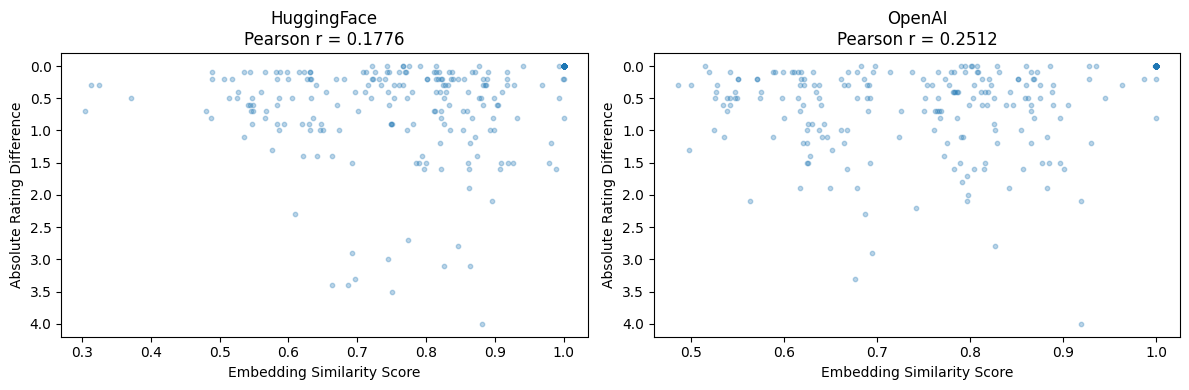

Plot saved


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sims, diffs, label, corr in zip(
    axes,
    [hf_sims, openai_sims],
    [hf_diffs, openai_diffs],
    ["HuggingFace", "OpenAI"],
    [hf_corr, openai_corr]
):
    ax.scatter(sims, diffs, alpha=0.3, s=10)
    ax.set_xlabel("Embedding Similarity Score")
    ax.set_ylabel("Absolute Rating Difference")
    ax.set_title(f"{label}\nPearson r = {corr:.4f}")
    ax.invert_yaxis()  # higher similarity at top = smaller rating gap

plt.tight_layout()
plt.savefig("rating_correlation_plot.png", dpi=150)
plt.show()
print("Plot saved")

In [28]:
with mlflow.start_run(run_name="rating_correlation_experiment"):
    mlflow.log_param("n_query_products", 50)
    mlflow.log_param("k_retrieved", 5)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("hf_pearson_r", hf_corr)
    mlflow.log_metric("hf_pvalue", hf_pval)
    mlflow.log_metric("openai_pearson_r", openai_corr)
    mlflow.log_metric("openai_pvalue", openai_pval)

    # Tag the finding
    better_model = "openai" if openai_corr > hf_corr else "huggingface"
    mlflow.set_tag("better_rating_alignment", better_model)

    mlflow.log_artifact("rating_correlation_plot.png")

print("\n=== EXPERIMENT CONCLUSION ===")
print(f"HuggingFace : r={hf_corr:.4f}  (p={hf_pval:.4f})")
print(f"OpenAI      : r={openai_corr:.4f}  (p={openai_pval:.4f})")
print(f"\nDo semantically similar products have similar ratings?")
print(f"{'YES — significant correlation found' if min(hf_pval, openai_pval) < 0.05 else 'WEAK — embeddings capture text similarity but not rating quality'}")


=== EXPERIMENT CONCLUSION ===
HuggingFace : r=0.1776  (p=0.0048)
OpenAI      : r=0.2512  (p=0.0001)

Do semantically similar products have similar ratings?
YES — significant correlation found
